In [1]:
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity

from slsim.Lenses.lens_pop import LensPop
from slsim.Plots.lens_plots import LensingPlots
from slsim.Deflectors.DeflectorPopulation.galaxy_deflectors import GalaxyDeflectors
from slsim.Sources.SourcePopulation.galaxies import Galaxies

import numpy as np
import corner
import slsim.Pipelines as pipelines

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


# Galaxy-galaxy simulations

This notebook walks through the basics of simulating a galaxy-galaxy strong lensing population.
The underlying 

assumptions of the galaxy populations (for both lenses and sources) are drawn from a population pre-configured

 and rendered through [SkyPy](https://github.com/skypyproject/skypy). The specific settings are described in the [readme file](https://github.com/LSST-strong-lensing/slsim/tree/gg-lensing/data/SkyPy).

The notebook goes in three steps:

1. The populations of lenses and sources is produced.
2. Random draws of the population are generated and realized as images
3. The full population is generated in catalogue form
4. the full population is represented in a corner plot



## Generate population of galaxies and (potential) deflectors
The LensPop() class in the Slsim package is used to produce a set lenses based on a set of sources and deflectors as seen on the sky within a certain sky area.

The deflector and source populations do not need to be specified for the same sky area. If the sky area is different for deflectors and sources, their numbers will be up- or down-sampled by the ratio of sky areas.

We use the default SkyPy configuration file. Alternative configuration files can be used.

In [2]:
# define a cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# define a sky area to render lenses for
sky_area = Quantity(value=10, unit="deg2")

# define sky area to render sources from (can be smaller if sample noise is suppressed enough)
sky_area_galaxies = Quantity(value=0.5, unit="deg2")


# define limits in the intrinsic deflector and source population (in addition to the skypy config
# file)
kwargs_deflector_cut = {"band": "g", "band_max": 26, "z_min": 0.01, "z_max": 2.5}
kwargs_source_cut = {"band": "g", "band_max": 26, "z_min": 0.1, "z_max": 5.0}

In [3]:
# Generate galaxy population using skypy pipeline.
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=None, sky_area=sky_area_galaxies, filters=None, cosmo=cosmo
)

In [4]:
# Initiate deflector population class.

lens_galaxies = GalaxyDeflectors(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut=kwargs_deflector_cut,
    kwargs_mass2light=None,
    catalog_type="skypy",
    cosmo=cosmo,
    sky_area=sky_area_galaxies,
)

print(
    "Number of galaxies that are potential deflectors is",
    lens_galaxies.deflector_number(),
)

Number of galaxies that are potential deflectors is 70284


In [5]:
# Initiate source population class.
source_galaxies = Galaxies(
    galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut=kwargs_source_cut,
    cosmo=cosmo,
    sky_area=sky_area_galaxies,
    catalog_type="skypy",
    extended_source_type="single_sersic",
)

In [6]:
# make galaxy-galaxy population class using LensPop
gg_lens_pop = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_galaxies,
    cosmo=cosmo,
    sky_area=sky_area,
)

## Generate images of random lenses
The LensingPlots() class has the functionality to draw random lenses and makes an image of it.
Currently

default settings in lenstronomy are chosen for the LSST image settings. These will be able to be replaced with the

LSST simulation tools.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


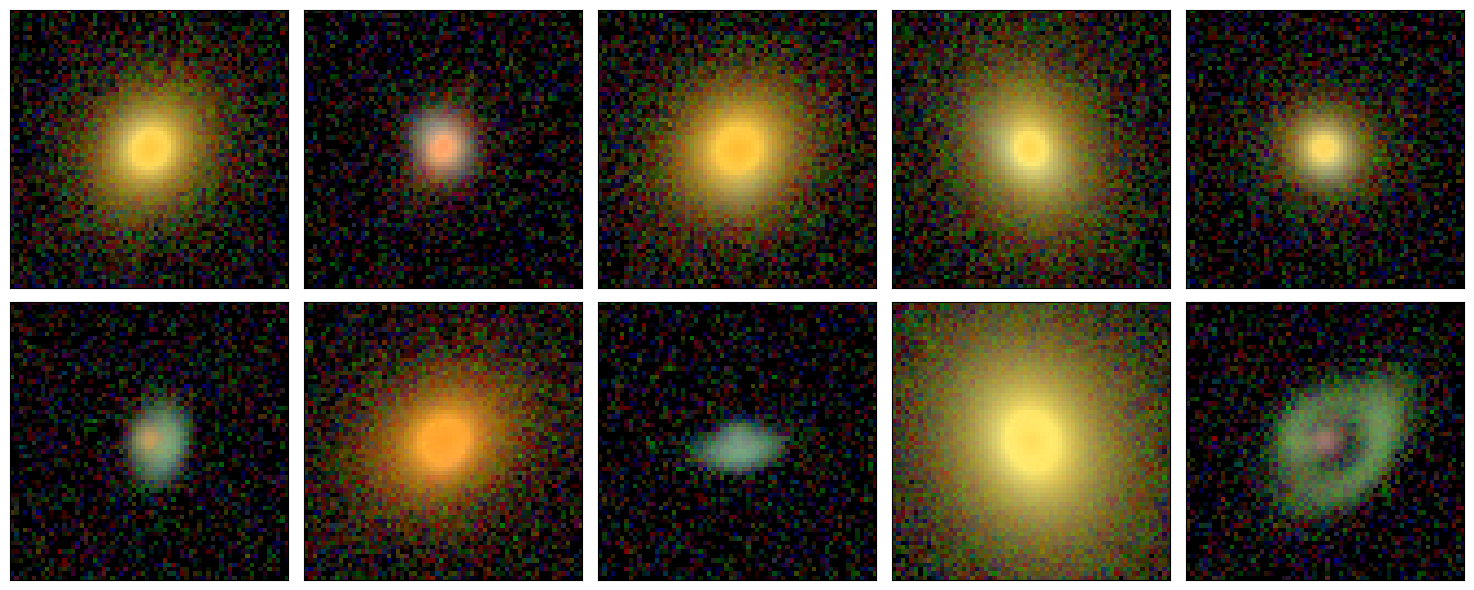

In [7]:
# make some cuts in the image separations and limited magnitudes of the arc
kwargs_lens_cut_plot = {
    "min_image_separation": 0.8,
    "max_image_separation": 10,
    "mag_arc_limit": {"g": 23, "r": 23, "i": 23},
}


gg_plot = LensingPlots(gg_lens_pop, num_pix=64, coadd_years=10)

# generate montage indicating which bands are used for the rgb color image
fig, axes = gg_plot.plot_montage(
    rgb_band_list=["i", "r", "g"],
    add_noise=True,
    n_horizont=5,
    n_vertical=2,
    kwargs_lens_cut=kwargs_lens_cut_plot,
)
plt.show()

## Generate the full population
We are using the instance of the LensPop() class to draw the full population within specified cuts in a Monte Carlo process.

The Monte Carlo process has the following steps:
1. goes through the list of possible deflectors as specified by the sky area
2. Calculates the maximum solid angle behind which a source can possibly be multiply-imaged (i.e. from the Einstein radius for a source at infinity
3. Based the source population density, calculates the probability of one or more sources being present in the solid angle of step (2)
4. Draws from the probibility of (3), if True, go to next step, otherwise go back to step (1) with another deflector
5. Position source randomly within the solid angle of step (3)
6. Solve the lens equaiton and calculate images
7. If multiple magnified images appear, accept system as a lens
8. (optional) other selection criteria, such as magnitude limits in the extended arc, image separation etc can be applied

To speed calculations up, not every possible deflector has to be considered. One can also only consider a fraction of the deflectors, and assign the higher probability weight of those to be actual deflectors (by virtue of assigning a higher source density). This is set as the 'speed_factor' in the 'draw_population' routine.


Useful tips:
- Do taylor the source and deflector population cuts (intrinsic cuts prior to lensing calculations). This can avoid a lot of proposed deflectors and sources that anyways will not make it through your lens selection cuts, and hence save time in the processing of your lenses.
- If you want to compute a large sky area, it is recommended to chose smaller deflector and source population sky areas, as their numbers will reach 'statistical completeness' at few deg2 depending on their abundances. Only for rare objects, larger deflector or source sky areas are required.
- To save memory, you can also compute the lens population in series of smaller sky areas. You can re-use the same LensPop() class instance and run multiple draw_population() calls.


In [8]:
# specifying cuts of the population
kwargs_lens_cuts = {"mag_arc_limit": {"g": 24}}
# drawing population
gg_lens_population = gg_lens_pop.draw_population(
    kwargs_lens_cuts=kwargs_lens_cuts, speed_factor=10
)

print("Number of lenses:", len(gg_lens_population))

Number of lenses: 560


## Represent key quantities of full population in corner plots
We calculate few key quantities of the lenses. The full population is represented each with a Lens() class

object that allows to compute and return these (and more) quantities.

In [9]:
lens_samples = []
labels = [
    r"$\sigma_v$",
    r"$\log(M_{*})$",
    r"$\theta_E$",
    r"$z_{\rm l}$",
    r"$z_{\rm s}$",
    r"$m_{\rm source}$",
    r"$m_{\rm lens}$",
]

for gg_lens in gg_lens_population:
    vel_disp = gg_lens.deflector_velocity_dispersion()
    m_star = gg_lens.deflector_stellar_mass()
    theta_e = gg_lens.einstein_radius[0]
    zl = gg_lens.deflector_redshift
    zs = gg_lens.source_redshift_list[0]
    source_mag = gg_lens.extended_source_magnitude(band="g", lensed=True)[0]
    deflector_mag = gg_lens.deflector_magnitude(band="g")
    lens_samples.append(
        [vel_disp, np.log10(m_star), theta_e, zl, zs, source_mag, deflector_mag]
    )

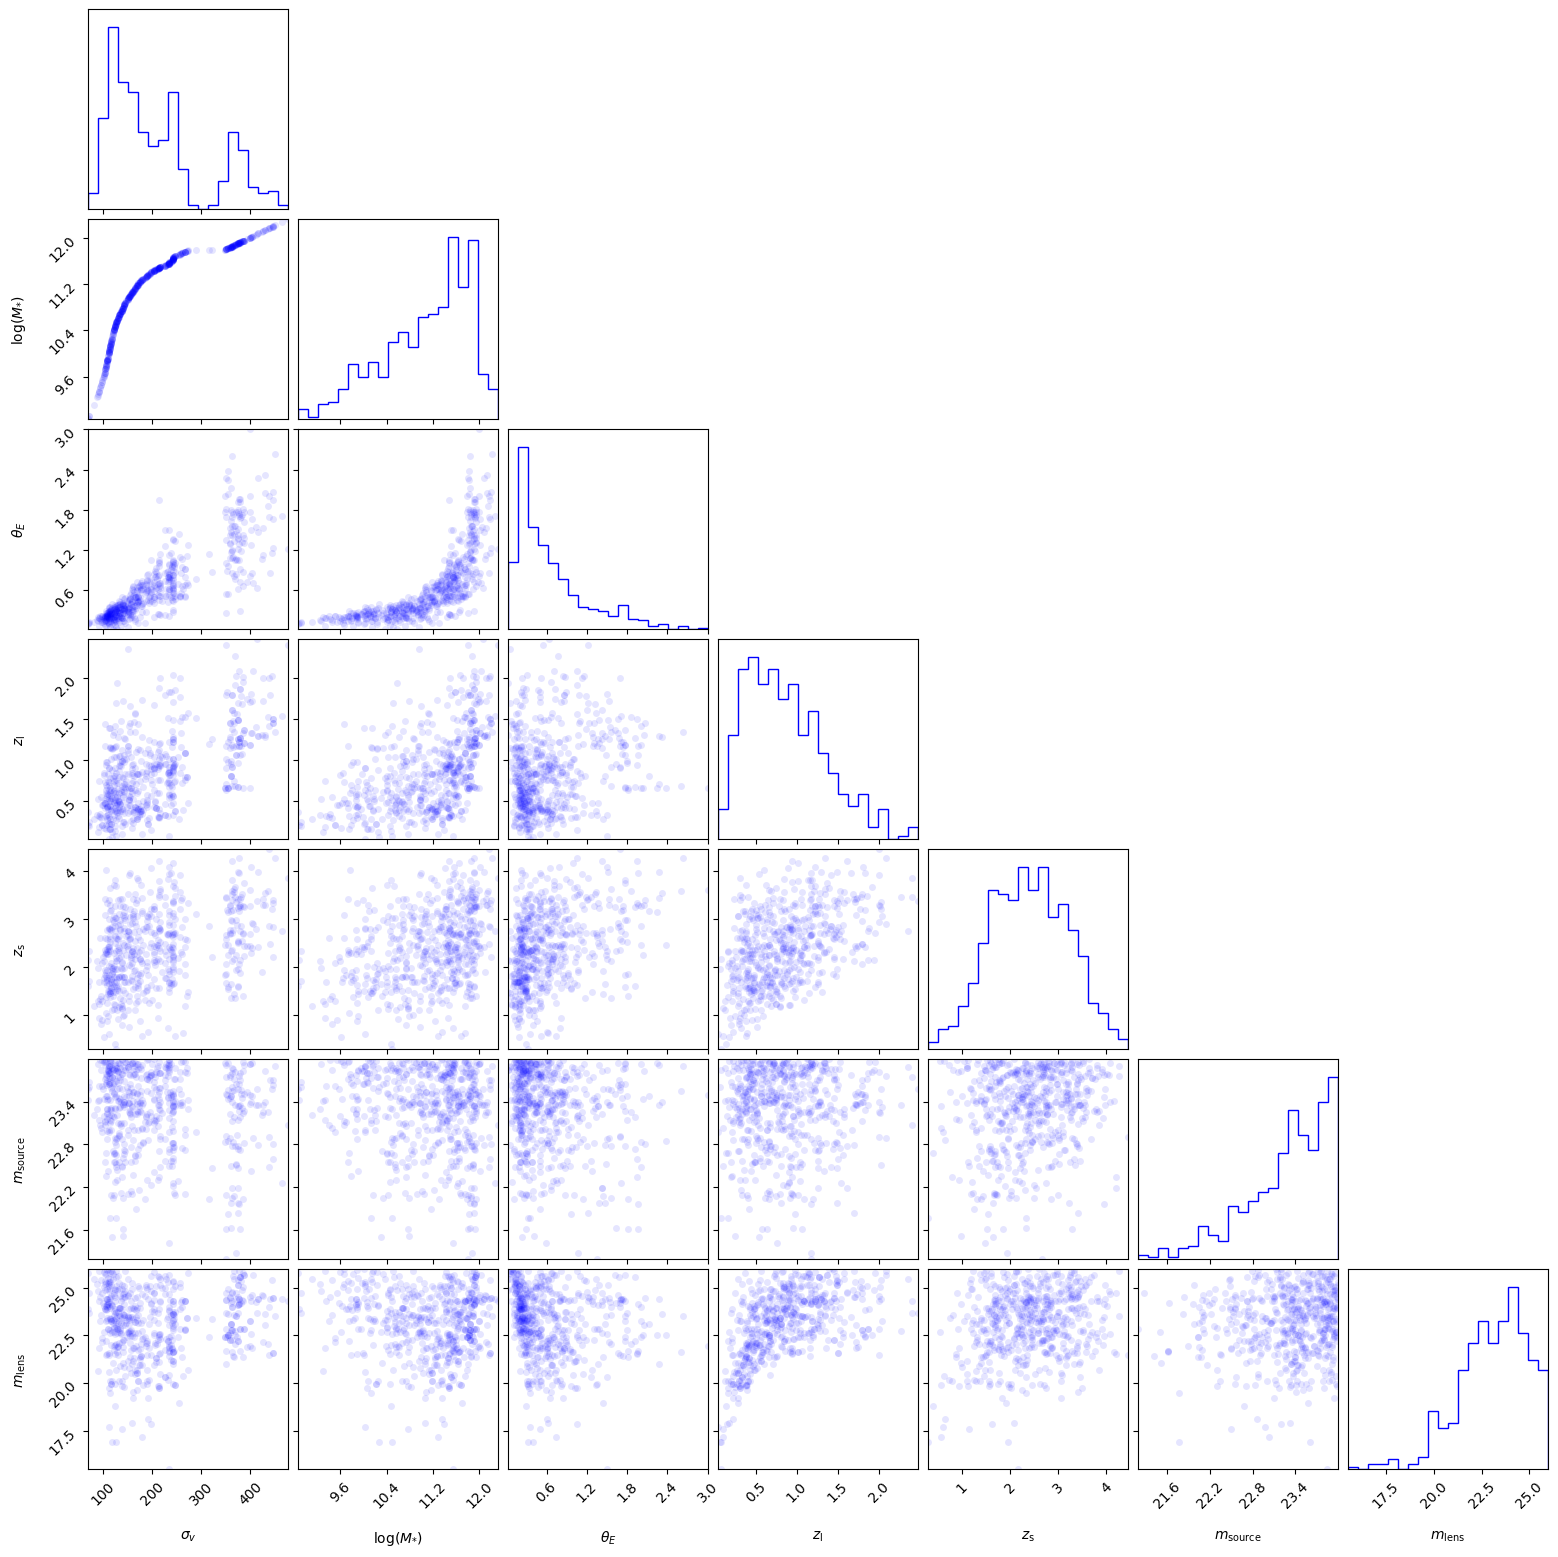

In [10]:
hist2dkwargs = {
    "plot_density": False,
    "plot_contours": False,
    "plot_datapoints": True,
    "color": "b",
    "data_kwargs": {"ms": 5},
}
corner.corner(np.array(lens_samples), labels=labels, **hist2dkwargs)
plt.show()